<h1 style="text-align: center;">[   REPORT PLOTS    ]</h1>

In [5]:
import numpy as np
import matplotlib.pyplot as plt

### 1) Pulse frequency as a function of obstacle distance


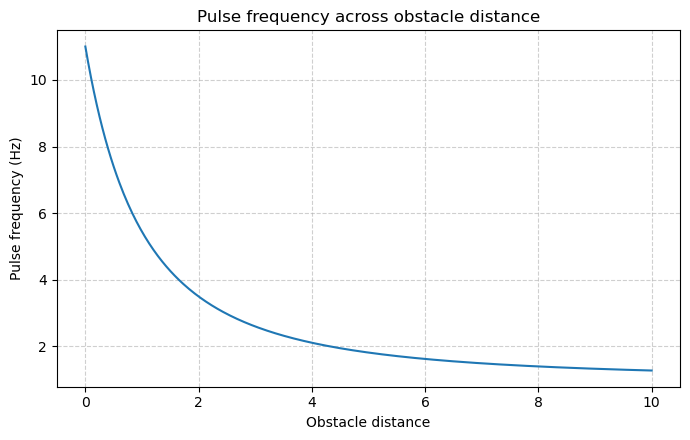

In [14]:
k = 40
o = 1
epsilon = 2

# Distance in the range of interest (adjust upper bound if needed)
dist = np.linspace(0, 10, 400)
pulse_rate = k / (dist + epsilon)**2 + o

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(dist, pulse_rate, color='tab:blue')
ax.set_title('Pulse frequency across obstacle distance')
ax.set_xlabel('Obstacle distance')
ax.set_ylabel('Pulse frequency (Hz)')
ax.grid(True, linestyle='--', alpha=0.6)
fig.tight_layout()
plt.show()
fig.savefig('pulse_distance_plot.png', dpi=900)


### 2) Directuional attenuation heatmap


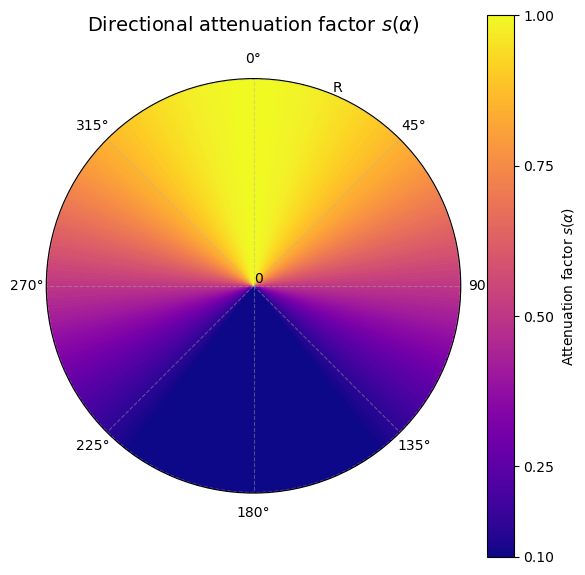

In [33]:
# Directional attenuation heatmap on a polar grid
R_max = 1.0
theta = np.linspace(0, 2 * np.pi, 361)
r = np.linspace(0, R_max, 150)

Theta, Rad = np.meshgrid(theta, r)
attenuation = (np.cos(Theta) + 1) / 2 
# Clamp at 0.1 to avoid complete attenuation
attenuation = np.clip(attenuation, 0.1, 1.0)
norm = plt.Normalize(vmin=0.1, vmax=1.0)

fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(6, 6))
c = ax.pcolormesh(Theta, Rad, attenuation, shading="auto", cmap="plasma", norm=norm)
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_title(r'Directional attenuation factor $s(\alpha)$', pad=16, fontsize=14)
ax.set_yticks([0, R_max])
ax.set_yticklabels(["0", "R"])
ax.grid(True, linestyle="--", alpha=0.4)
cbar = fig.colorbar(c, ax=ax, label=r'Attenuation factor $s(\alpha)$')
cbar.set_ticks([0.1, 0.25, 0.5, 0.75, 1.0])
fig.tight_layout()
plt.show()
fig.savefig("directional_heatmap.png", dpi=900)
